<a href="https://colab.research.google.com/github/niikun/ezkl/blob/main/proof_splitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ProofSplitting  
#### 概要
この機能は、巨大なニューラルネットワークを1つの大きな回路（Circuit）として扱うのではなく、複数の小さな回路に分割して証明を生成する仕組みです。これには主に2つの大きなメリットがあります。
- メモリ（RAM）要件の削減: 1台の強力なマシンがなくても、段階的に処理することでピークメモリを抑えられます。
- 分散処理: 複数のマシンに負荷を分散して、並列（またはパイプライン）で証明を生成できます。

#### 2つのアプローチ（回路の結合方法）
分割された回路同士を繋ぎ合わせる（ステッチする）方法として、EZKLでは以下の2つの設定が用意されています。
- Public Instances  
回路Aの出力（中間計算結果）をパブリック・インプットとして公開し、そのまま回路Bの入力に渡します。  
ユースケース:  中間データに機密情報や独自のノウハウが含まれておらず、公開されても問題ない場合。
- KZG Commitments  
中間計算結果を隠したまま、軽量な多項式コミットメント（KZG）を生成します。回路Bはそのコミットメントに対して検証を行います。  
ユースケース:  中間データを完全に秘密にしたいが、ブラインディング（目隠し）によるパフォーマンス低下を避けたい場合。

#### 全体のパイプライン（流れ）
1. モデルの定義と切り出し:   
PyTorchなどでモデルを定義した後、ONNXのユーティリティ（onnx.utils.extract_model）を使って、モデルを物理的に複数の部分グラフ（例: network_split_0.onnx, network_split_1.onnx）に切り出します。

2. 設定とキャリブレーション:   
各サブモデルに対して ezkl.gen_settings() と ezkl.calibrate_settings() を個別に実行し、適切なスケールや回路のサイズ（logrows）を決定します。

3. 証拠（Witness）の生成:   
最初の回路の出力が、次の回路の入力データとなるように連鎖させて部分的なウィットネスを生成します。

4. 証明の生成とコミットメントのスワップ:  
 各モデルを順番に証明します。結合の際には ezkl.swap_proof_commitments() を使用して、前の回路の出力と次の回路の入力が一致していることを保証した上で、最終的な検証（Verify）を行います。

In [1]:
# check if notebook is in colab
try:
    # install ezkl
    import google.colab
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ezkl"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "onnx"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "onnxscript"])

# rely on local installation of ezkl if the notebook is not in colab
except:
    pass

from torch import nn
import ezkl
import os
import json
import logging

# uncomment for more descriptive logging
# FORMAT = '%(levelname)s %(name)s %(asctime)-15s %(filename)s:%(lineno)d %(message)s'
# logging.basicConfig(format=FORMAT)
# logging.getLogger().setLevel(logging.INFO)

In [2]:

import torch
# Defines the model
# we got convs, we got relu,
# What else could one want ????

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=2, stride=4)
        self.conv2 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=2, stride=4)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)

        return x

    def split_1(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        return x


circuit = MyModel()

# this is where you'd train your model

## Modelの分割  
まず、torch.onnx.export を使って、PyTorchで定義したモデル全体を network.onnx というONNX形式のファイルにエクスポートしました。

次に、onnx.utils.extract_model を使用して、この network.onnx を2つのサブモデルに分割しました。

- network_split_0.onnx:   
input から conv1 と最初の relu の出力までを担当します。 (/conv1/Conv_output_0 がその中間出力です)
- network_split_1.onnx:  
 conv1 と最初の relu の出力 (/conv1/Conv_output_0) を入力として受け取り、最終的な出力 (output) までを担当します。  


これは、元の大きなモデルを、それぞれ独立して証明を生成できる小さなパーツに分解する作業です。これにより、メモリ要件の削減や分散処理が可能になります。

次に、これらの分割されたモデルごとにezkl.gen_settings()とezkl.calibrate_settings()を実行して、それぞれの回路設定を生成し、適切なスケールや回路のサイズ（logrows）を決定します。これは、ZKP（ゼロ知識証明）を生成するために必要な初期設定となります。

In [3]:
x = torch.rand(1,*[3, 8, 8], requires_grad=True)

# Flips the neural net into inference mode
circuit.eval()

    # Export the model
torch.onnx.export(circuit,               # model being run
                      x,                   # model input (or a tuple for multiple inputs)
                      os.path.join(os.getcwd(), "network.onnx"),            # where to save the model (can be a file or file-like object)
                      export_params=True,        # store the trained parameter weights inside the model file
                      opset_version=10,          # the ONNX version to export the model to
                      do_constant_folding=True,  # whether to execute constant folding for optimization
                      input_names = ['input'],   # the model's input names
                      output_names = ['output'], # the model's output names
                      dynamic_axes={'input' : {0 : 'batch_size'},    # variable length axes
                                    'output' : {0 : 'batch_size'}},
                      dynamo=False)


data_path = os.path.join(os.getcwd(), "input_0.json")
data = dict(input_data = [((x).detach().numpy()).reshape([-1]).tolist()])
json.dump( data, open(data_path, 'w' ))

inter_1 = circuit.split_1(x)
data_path = os.path.join(os.getcwd(), "input_1.json")
data = dict(input_data = [((inter_1).detach().numpy()).reshape([-1]).tolist()])
json.dump( data, open(data_path, 'w' ))

/tmp/ipykernel_26386/3631881776.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(circuit,               # model being run


In [4]:
import pprint
pprint.pprint(data)

{'input_data': [[0.9002504944801331,
                 1.0665149688720703,
                 0.5303826332092285,
                 0.673774242401123]]}


## Netronで中身を確認

以下でモデルの分割場所を設定。具体的にはoutputsの場所を指定。  
https://netron.app/

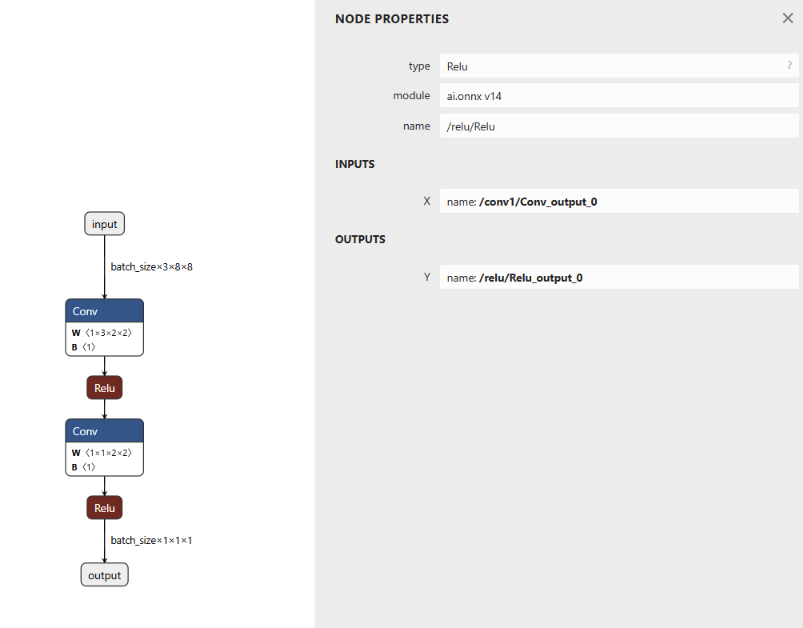

#### first model

In [5]:

import onnx

input_path = "network.onnx"
output_path = "network_split_0.onnx"
input_names = ["input"]
output_names = ["/relu/Relu_output_0"]
# first model
onnx.utils.extract_model(input_path, output_path, input_names, output_names)

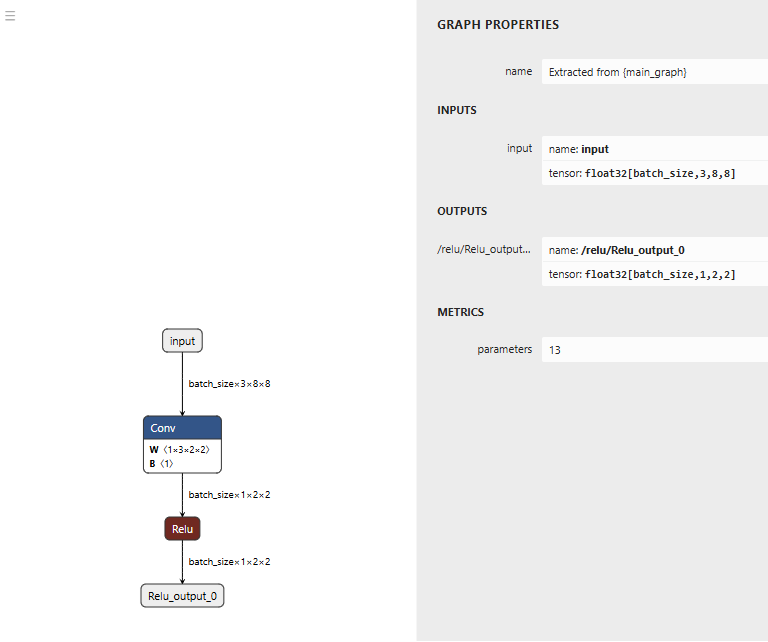

#### second model

In [6]:

input_path = "network.onnx"
output_path = "network_split_1.onnx"
input_names = ["/relu/Relu_output_0"]
output_names = ["output"]
# second model
onnx.utils.extract_model(input_path, output_path, input_names, output_names)

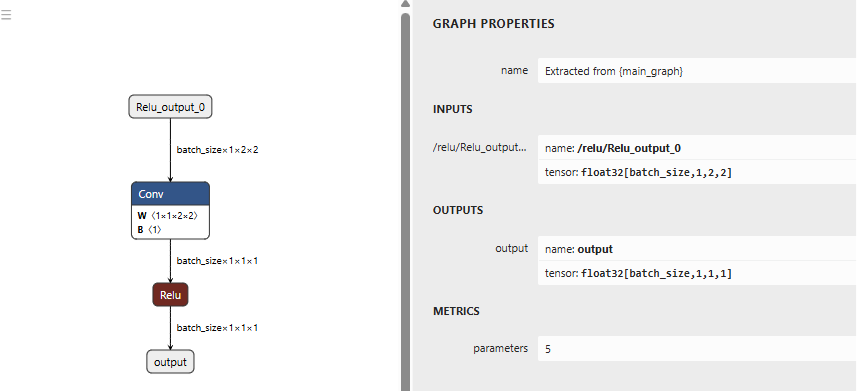

## 公開中間計算（Public intermediate calculations）
ここからが本題です。モデルの可視性（visibility）パラメータを格納する `PyRunArgs` オブジェクトを定義します。

* **`input_visibility`**: モデルの入力データの可視性を定義します。
* **`param_visibility`**: モデルの重み、定数、パラメータの可視性を定義します。
* **`output_visibility`**: モデルの出力結果の可視性を定義します。

現在、**5つの可視性設定（Visibility Settings）**が利用可能です：

1. **`public`（公開）**: 検証者（Verifier）と証明者（Prover）の両方がデータを把握している状態。（※モデルパラメータに関しては若干のニュアンスの違いがあるかもしれませんが、より厳密な理論的結果が得られるまでは、ここでは強い主張は控えます）。
2. **`private`（秘密）**: 証明者のみがデータを知っている状態。
3. **`hashed`（ハッシュ化）**: 証明者はハッシュの元のデータ（プレイメージ）を知っており、証明者と検証者の両方はそのハッシュ値を知っている状態。証明者は「自分がそのハッシュ値に対応する元データを知っていること」を証明します。
4. **`encrypted`（暗号化）**: 証明者は、暗号化されていない要素と復号に使用する秘密鍵を知っている状態。証明者と検証者は、暗号化された要素、暗号化に使用した公開鍵、および復号鍵のハッシュ値を知っています。証明者は「自分がハッシュ化された復号鍵の元データを知っており、実際にその鍵で暗号文を復号できること」を証明します。
5. **`polycommit`（多項式コミットメント）**: KZGコミットメントを生成する、目隠しなしの助言列（unblinded advice column）。これは回路のインスタンス（公開入力）には現れず、証明のバイトデータ（proof bytes）内で直接変更する必要があります。

ここでは、以下のセットアップを作成します：
* `input_visibility`: `"public"`
* `param_visibility`: `"fixed"　※publicは現在非推奨`
* `output_visibility`: `"public"`

次に、ONNXモデルのエクスポートと中間入力/出力のJSONファイルのパスを更新します。

## 公開パラメータ取得
EZKL（ゼロ知識証明を用いた機械学習のライブラリ）において、証明の作成と検証に必要な「公開パラメータ（SRS：Structured Reference String）」を取得（またはダウンロード）する処理を行っています。詳しく分解すると、以下のような意味を持っています。  

**1. get_srs とは？SRS（Structured Reference String：**  
構造化参照文字列）を取得する関数です。EZKLが裏側で使用しているゼロ知識証明のスキーム（KZGコミットメントなど）では、回路の正しさを証明するために、事前に生成された数学的な信頼できるパラメータ（SRS）が必要になります。この関数を実行すると、指定されたサイズに応じたSRSファイルがローカルにキャッシュ（またはダウンロード）されます。
**2. logrows=run_args.logrows とは？回路の規模（行数の対数：**
$2^{\text{logrows}}$）を指定しています。先ほどの設定で run_args.logrows = 15 と指定されているため、ここでは $2^{15} = 32,768$ 行の数式（制約）を処理できるサイズ（スケール）のSRSを要求しています。ニューラルネットワークのレイヤー数が多かったり、パラメータが大きくなったりするほど、この logrows の値を大きくする必要があり、それに伴って必要なSRSのサイズも大きくなります。

In [7]:
import ezkl

data_path = os.path.join(os.getcwd(),"input.json")
run_args = ezkl.PyRunArgs()
run_args.input_visibility = "public"
run_args.param_visibility = "fixed"
run_args.output_visibility = "public"

run_args.input_scale = 2
run_args.logrows = 15
await ezkl.get_srs(logrows=run_args.logrows)

True

#### 毎回ファイルを書き出す理由  
**1. メモリ（RAM）の消費を極限まで抑えるため**
Proof Splittingの最大の目的は、「1台のマシンにかかるメモリ負荷を減らすこと」です。
ZK-SNARKの証明生成（特に ezkl.prove や ezkl.gen_witness）は膨大なメモリを消費します。もし分割したパーツすべてのデータ（Witnessやモデル情報）を変数として保持し続けると、それだけでメモリが圧迫されてプログラムがクラッシュ（OOM: Out of Memory）してしまいます。
不要なときは一度ファイルとしてディスク（ストレージ）に逃がし、「いま必要なサブモデルのデータだけをメモリに載せる」という戦略をとっています。  

**2. 「別々のマシン」で処理することを想定しているため（分散処理）**
このサンプルコードは1つのJupyterノートブックで動いていますが、実際の運用では以下のような分散処理（パイプライン）を想定しています。  

    マシンA：サブモデル0の計算（証拠の生成と証明）を行い、結果（witness_split_0.json）を保存する。

    マシンB：マシンAの保存したファイルを受け取り、それを入力としてサブモデル1の計算を始める。  

データをファイルにしておけば、クラウドストレージなどを経由して別のサーバーや別のプロセスに簡単にデータを引き渡せるようになります。  

**3. ZKのツール（EZKLのコア）がファイルを要求するため**
EZKLの内部（Rustで書かれたコアエンジン）は、効率よくセキュアに処理を行うために、基本的に入力や証拠（Witness）をファイルのパス（String）として受け取る設計になっています。そのため、Python側で一度JSONファイルとして物理的に保存してあげる必要があります。

## 証明

In [8]:
async def setup(i):
    # file names
    model_path = os.path.join('network_split_'+str(i)+'.onnx')
    settings_path = os.path.join('settings_split_'+str(i)+'.json')
    data_path =  os.path.join('input_'+str(i)+'.json')
    compiled_model_path = os.path.join('network_split_'+str(i)+'.compiled')
    pk_path = os.path.join('test_split_'+str(i)+'.pk')
    vk_path = os.path.join('test_split_'+str(i)+'.vk')
    witness_path = os.path.join('witness_split_'+str(i)+'.json')

    if i > 0:
         prev_witness_path = os.path.join('witness_split_'+str(i-1)+'.json')
         witness = json.load(open(prev_witness_path, 'r'))
         data = dict(input_data = witness['outputs'])
         # Serialize data into file:
         json.dump(data, open(data_path, 'w' ))
    else:
         data_path = os.path.join('input_0.json')

    # generate settings for the current model
    res = ezkl.gen_settings(model_path, settings_path, py_run_args=run_args)
    res = ezkl.calibrate_settings(data_path, model_path, settings_path, "resources", scales=[run_args.input_scale], max_logrows=run_args.logrows)
    assert res == True

    # load settings and print them to the console
    settings = json.load(open(settings_path, 'r'))
    settings['run_args']['logrows'] = run_args.logrows
    json.dump(settings, open(settings_path, 'w' ))

    res = ezkl.compile_circuit(model_path, compiled_model_path, settings_path)


    res = ezkl.setup(
         compiled_model_path,
         vk_path,
         pk_path,
      )

    assert res == True
    assert os.path.isfile(vk_path)
    assert os.path.isfile(pk_path)

    res = ezkl.gen_witness(data_path, compiled_model_path, witness_path, vk_path)
    run_args.input_scale = settings["model_output_scales"][0]

for i in range(2):
    await setup(i)


 <------------- Numerical Fidelity Report (input_scale: 2, param_scale: 2, scale_input_multiplier: 10) ------------->

+--------------+--------------+-------------+-------------+----------------+------------------+---------------+---------------+--------------------+--------------------+------------------------+
| mean_error   | median_error | max_error   | min_error   | mean_abs_error | median_abs_error | max_abs_error | min_abs_error | mean_squared_error | mean_percent_error | mean_abs_percent_error |
+--------------+--------------+-------------+-------------+----------------+------------------+---------------+---------------+--------------------+--------------------+------------------------+
| -0.051019385 | -0.09461737  | 0.004015088 | -0.09461737 | 0.05302693     | 0.09461737       | 0.09461737    | 0.004015088   | 0.004041616        | -0.0822848         | 0.084167145            |
+--------------+--------------+-------------+-------------+----------------+------------------+-----

### ezkl.swap_proof_commitments()
Proof Splitting（証明の分割）において最もキモとなる超重要ステップです。
  
一言でいうと、「前段のサブモデルの出力と、後段のサブモデルの入力が、改ざんされずに正しくバトンタッチされているか」を証明の中に埋め込む（ステッチする）処理を行っています。

詳しく噛み砕くと、以下のような処理が裏で動いています。

**1. なぜこれが必要なのか？（解決したい課題）**
分割して証明を生成するとき、普通にそれぞれで証明を作っただけだと、悪意のある証明者が以下のような不正（チート）を働くリスクがあります。

    サブモデル0（前段）：正しい入力を使って、出力 A を計算したと証明する。

    サブモデル1（後段）：都合の良い別の入力 B を勝手に使って、最終出力を計算したと証明する。

これだと、モデル全体として正しい計算が行われたことになりません。前段の出力と後段の入力が「寸分の狂いもなく完全に一致していること」を保証する必要があります。

**2. 具体的に何をしているのか？**
この関数を呼び出す直前のコードで、以下のようにデータを上書きしていました。

```
witness["processed_inputs"] = prev_witness["processed_outputs"]
```
これは「前段の出力」を「後段の入力」に上書きコピーした状態です。

そして ezkl.swap_proof_commitments(proof_path, witness_path) を実行すると、EZKLは以下の処理を行います。

- コミットメント（暗号的な指紋）の抽出：  
上書きした witness_path（後段のWitnessファイル）から、前段の出力に由来するデータ部分の「暗号的な指紋（多項式コミットメント）」を計算します。

- 証明の書き換え（スワップ）：  
proof_path（後段の証明ファイル）の内部に記録されている入力コミットメントを、1で計算した指紋へと物理的に差し替えて（スワップして）証明をアップデートします。

**3. この後の ezkl.verify() でどうなる？**  

このスワップ処理を行った後に全体の検証（ezkl.verify）を走らせることで、検証者（Verifier）は、「確かにこの後段の証明は、前段の出力データをそのまま入力として使って作られたものだ」ということを、データを生身で公開することなく暗号論的に100%確信できるようになります。
  
** 💡 一言でまとめると**   

分割された証明のパーツ同士を、パズルのピースのように**「ガチッと結合して1本の信頼できる鎖（パイプライン）にするための接着剤」**のような役割を持っている関数です！

In [9]:
def prove_model(i):
    proof_path = os.path.join('proof_split_'+str(i)+'.json')
    witness_path = os.path.join('witness_split_'+str(i)+'.json')
    compiled_model_path = os.path.join('network_split_'+str(i)+'.compiled')
    pk_path = os.path.join('test_split_'+str(i)+'.pk')
    vk_path = os.path.join('test_split_'+str(i)+'.vk')
    settings_path = os.path.join('settings_split_'+str(i)+'.json')

    # 各モデルをまず証明
    res = ezkl.prove(
        witness_path,
        compiled_model_path,
        pk_path,
        proof_path
    )

    print(f"modelの証明：{res}")
    res_1_proof = res["proof"]
    assert os.path.isfile(proof_path)

    if i > 0:
        print("swapping commitments")
        # input,outpuがpublicのときは　None->Noneだが、privateなどの場合必要
        ## split_0のwitnessを呼び出す
        prev_witness_path = os.path.join('witness_split_'+str(i-1)+'.json')
        prev_witness = json.load(open(prev_witness_path, 'r'))
        witness = json.load(open(witness_path, 'r'))
        print(prev_witness["processed_outputs"])
        print(witness["processed_inputs"])
        ## split0のprocessed_outputsをsplit1のprocessed_inputに代入
        witness["processed_inputs"] = prev_witness["processed_outputs"]
        with open(witness_path, "w") as f:
            json.dump(witness, f)
        ### ここがポイント ###
        res = ezkl.swap_proof_commitments(proof_path, witness_path)
        print(res)

        proof = json.load(open(proof_path, 'r'))
        res_2_proof = proof["hex_proof"]
        # show diff in hex strings
        print(res_1_proof)
        print(res_2_proof)
        assert res_1_proof == res_2_proof

    res = ezkl.verify(
            proof_path,
            settings_path,
            vk_path,
        )

    assert res == True
    print("verified")

for i in range(2):
    prove_model(i)


modelの証明：{'instances': [['0300000000000000000000000000000000000000000000000000000000000000', '0300000000000000000000000000000000000000000000000000000000000000', '0200000000000000000000000000000000000000000000000000000000000000', '0200000000000000000000000000000000000000000000000000000000000000', '0400000000000000000000000000000000000000000000000000000000000000', '0400000000000000000000000000000000000000000000000000000000000000', '0300000000000000000000000000000000000000000000000000000000000000', '0100000000000000000000000000000000000000000000000000000000000000', '0400000000000000000000000000000000000000000000000000000000000000', '0200000000000000000000000000000000000000000000000000000000000000', '0000000000000000000000000000000000000000000000000000000000000000', '0200000000000000000000000000000000000000000000000000000000000000', '0300000000000000000000000000000000000000000000000000000000000000', '0100000000000000000000000000000000000000000000000000000000000000', '0300000000000000000000

modelの証明：{'instances': [['0f00000000000000000000000000000000000000000000000000000000000000', '1100000000000000000000000000000000000000000000000000000000000000', '0a00000000000000000000000000000000000000000000000000000000000000', '0c00000000000000000000000000000000000000000000000000000000000000', '4500000000000000000000000000000000000000000000000000000000000000']], 'proof': '0x1c61add33386ca2b33cdfb497b4297f70bd88ead52a9522c0a43ba3189be717b29760298c6982da80785c7d19ea13495623bace98fa57cff61d9df598fb256c01b81df208f5348799c6c88d82f9767f45ffe35db1fb86767678d61695a2c89f50f77ded3d174591fac959572abb4acdba5511a09d8b3f04b0a2f856dfca0ea941bf61ba0255380956816681c1b49e21cc1d8d3a11d8a9bd9d3ec9abd3b38cc7929ac1d473a4b08584492b99814b4b02ff4daa473bffd182c1304c533e94ac0fc0caa289d66fc7d57728a570361725ff0401c4d1a3838b590f492bf7e535634c0111d59b72325f52d043315c1c4eca16b75f82d769aaa4ce1fa722d7fb4495a6b10904921f755d5a8f2139ee6f5b7ee0e3b3e2f3d3da970a6d1534b79ac4d236702e7ba775aba17ca6bf19b708b836e8d3fecc150bbdd7

## 追加

In [10]:
data_path = os.path.join(os.getcwd(),"input.json")
run_args = ezkl.PyRunArgs()
run_args.input_visibility = "polycommit"
run_args.param_visibility = "fixed"
run_args.output_visibility = "polycommit"

run_args.input_scale = 2
run_args.logrows = 15
await ezkl.get_srs(logrows=run_args.logrows)




True

In [11]:
for i in range(2):
    await setup(i)


 <------------- Numerical Fidelity Report (input_scale: 2, param_scale: 2, scale_input_multiplier: 10) ------------->

+--------------+--------------+-------------+-------------+----------------+------------------+---------------+---------------+--------------------+--------------------+------------------------+
| mean_error   | median_error | max_error   | min_error   | mean_abs_error | median_abs_error | max_abs_error | min_abs_error | mean_squared_error | mean_percent_error | mean_abs_percent_error |
+--------------+--------------+-------------+-------------+----------------+------------------+---------------+---------------+--------------------+--------------------+------------------------+
| -0.051019385 | -0.09461737  | 0.004015088 | -0.09461737 | 0.05302693     | 0.09461737       | 0.09461737    | 0.004015088   | 0.004041616        | -0.0822848         | 0.084167145            |
+--------------+--------------+-------------+-------------+----------------+------------------+-----

In [12]:
for i in range(2):
    prove_model(i)

modelの証明：{'instances': [[]], 'proof': '0x11feaec39ecf330ec8f440083c906755b349690b6bffecc99bb219543b7e9ac31747ae3d1f76f3f522de8c29439105faf6aef75e99210c04dba46931fa848cf2071d629517d7c4700a914ccc5673fc252eb773e6df3fcda353b2334a2ecbd6fb10db77788eca75425791f7e274ca8bc2e09a23254db4bb543981db461bb5fce91b337894b8bba21edd7d6cae5002a31cf18f72983f04bbb3e55b60e13b07669f17de232aad0ec3d7c73a3be81f635f77e9084e45f95a4f9edf00e52625fcbc4508a19ecc04f534375a8e5c6ba0324aaaf2cbd9d6d166bd76ea891758b13147502e3692b65f4949e826b1416eeeae5ef0c38bc9ace4c24912c2c948dc2fcdd18604f89489d01af7af042813e33bb3ab4c6487d1e50d935502cf5a0c6d54200bcf1f00837ff699448a350030c4b5a633708182bf52e7d281e12ff8b14b14676367063d4231a5ea7937889f3d4e4abdef39748923cc3f2a1f198ba1d7e58b9e108225ef1cad7d1d157bc9fd88ee56f4d1c450003e4ed670cc50dcae4252bdd2ead326b0bcd28221e92233908f1a865347a268a696e09677a008557a180ddb194f17240a9353ff51e94e4c3cad4515f65a804a2508f735dac2088f5fd4d07297bbbe084cf6d1294e90b643315ea5d59f77d42c882f5d1dbd821feac9d9dc58eda07